**Step-1**

In [ ]:
import pandas as pd
import numpy as np

# 1. Setup Parameters
n_rows = 260
np.random.seed(42)  # Ensures the "random" data is the same every time you run it

# 2. Generate Feature Columns
data = {
    'Employee_ID': range(101, 101 + n_rows),
    'Age': np.random.randint(22, 60, size=n_rows),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], size=n_rows),
    'Education': np.random.choice(['Bachelors', 'Masters', 'PhD'], size=n_rows),
    'Department': np.random.choice(['IT', 'HR', 'Sales', 'Marketing', 'Finance'], size=n_rows),
    'Experience': np.random.randint(0, 35, size=n_rows),
    'Working_Hours': np.random.randint(35, 55, size=n_rows),
    'Performance_Score': np.random.randint(1, 100, size=n_rows),
    'Projects_Completed': np.random.randint(1, 15, size=n_rows)
}

# 3. Create DataFrame
df = pd.DataFrame(data)

# 4. Generate a Logical Salary (Base + Experience + Education)
# This ensures your Machine Learning model actually has a pattern to find later
df['Salary'] = (df['Experience'] * 2000) + (df['Age'] * 500) + np.random.randint(30000, 50000, size=n_rows)

# 5. Export to CSV
df.to_csv('employee_data.csv', index=False)

print("File 'employee_data.csv' has been created with 260 rows.")

File 'employee_data.csv' has been created with 260 rows.


**Step-2**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# 1. Load the dataset
df = pd.read_csv('employee_data.csv')

In [ ]:
# 2. Handle missing values
# (Checking and removing any null rows if they exist)
df = df.dropna()


In [ ]:
# 3. Remove duplicates
df = df.drop_duplicates()


In [ ]:
# 4. Encode categorical values
# We convert text columns (Gender, Education, Department) into numerical labels
le = LabelEncoder()
categorical_cols = ['Gender', 'Education', 'Department']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
# 5. Define Features (X) and Target (y)
# We drop 'Employee_ID' as it's just an identifier, and 'Salary' because it's what we want to predict
X = df.drop(['Employee_ID', 'Salary'], axis=1)
y = df['Salary']


In [ ]:
# 6. Perform train-test split
# We split the data: 80% for training the model and 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 7. Feature scaling
# We standardize the features so they have a mean of 0 and a variance of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Display results
print("--- Preprocessing Complete ---")
print(f"Total rows after cleaning: {len(df)}")
print(f"Training set size: {X_train_scaled.shape[0]} rows")
print(f"Testing set size: {X_test_scaled.shape[0]} rows")
print("\nSample of Scaled Features (First 5 rows):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

--- Preprocessing Complete ---
Total rows after cleaning: 260
Training set size: 208 rows
Testing set size: 52 rows

Sample of Scaled Features (First 5 rows):
        Age    Gender  Education  Department  Experience  Working_Hours  \
0 -1.015230 -1.147854  -1.111662   -0.047307   -1.165686       1.313455   
1  0.128596  0.089211   0.105315   -1.453001   -0.859288       0.069219   
2  1.624368  0.089211   1.322293   -1.453001   -1.472084      -1.530513   
3 -0.839257 -1.147854  -1.111662   -0.750154    1.081230      -1.352765   
4  1.096448  0.089211   0.105315    1.358387   -0.859288      -0.108529   

   Performance_Score  Projects_Completed  
0           1.509896           -1.371445  
1          -0.949368           -0.120302  
2          -0.152705            1.130841  
3           0.921058            0.880612  
4           1.163521            0.380155  


**Step-3**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# 1. Load and Prepare Categorical Data
df = pd.read_csv('employee_data.csv')
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df[col] = le.fit_transform(df[col])

# Create Category Target for Logistic Regression (Split into 3 groups)
bins = [0, df['Salary'].quantile(0.33), df['Salary'].quantile(0.66), np.inf]
df['Salary_Category'] = pd.cut(df['Salary'], bins=bins, labels=['Low', 'Medium', 'High'])
df['Salary_Cat_Encoded'] = le.fit_transform(df['Salary_Category'])

# Define Features and Targets
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category', 'Salary_Cat_Encoded'], axis=1)
y_continuous = df['Salary']
y_categorical = df['Salary_Cat_Encoded']

# Split and Scale
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_continuous, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- A. Linear Regression (Predict Exact Salary) ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)
y_pred_lr = lr_model.predict(X_test_scaled)

# --- B. Logistic Regression (Classify Salary Category) ---
log_model = LogisticRegression(multi_class='multinomial')
log_model.fit(X_train_scaled, y_train_clf)
y_pred_log = log_model.predict(X_test_scaled)

# --- C. Random Forest (Compare Performance) ---
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_scaled)

# Summary of Results
print(f"Linear Regression R2 Score: {r2_score(y_test_reg, y_pred_lr):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_clf, y_pred_log)*100:.2f}%")
print(f"Random Forest Regressor R2 Score: {r2_score(y_test_reg, y_pred_rf_reg):.4f}")
print(f"Random Forest Classifier Accuracy: {accuracy_score(y_test_clf, y_pred_rf_clf)*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Linear Regression R2 Score: 0.9466
Logistic Regression Accuracy: 84.62%
Random Forest Regressor R2 Score: 0.9280
Random Forest Classifier Accuracy: 82.69%


**Step-4**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Load dataset
df = pd.read_csv('employee_data.csv')


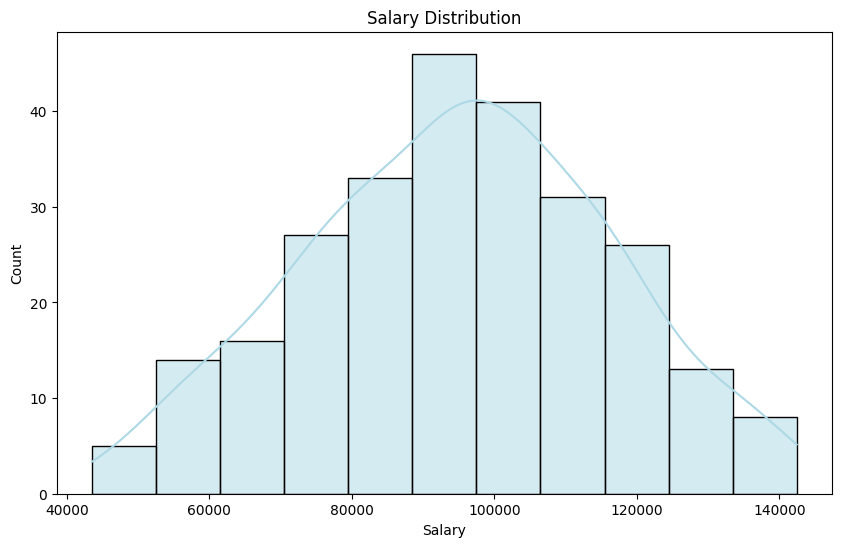

In [ ]:
# 1. Salary Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'], kde=True, color='lightblue')
plt.title('Salary Distribution')
plt.savefig('salary_distribution.png')


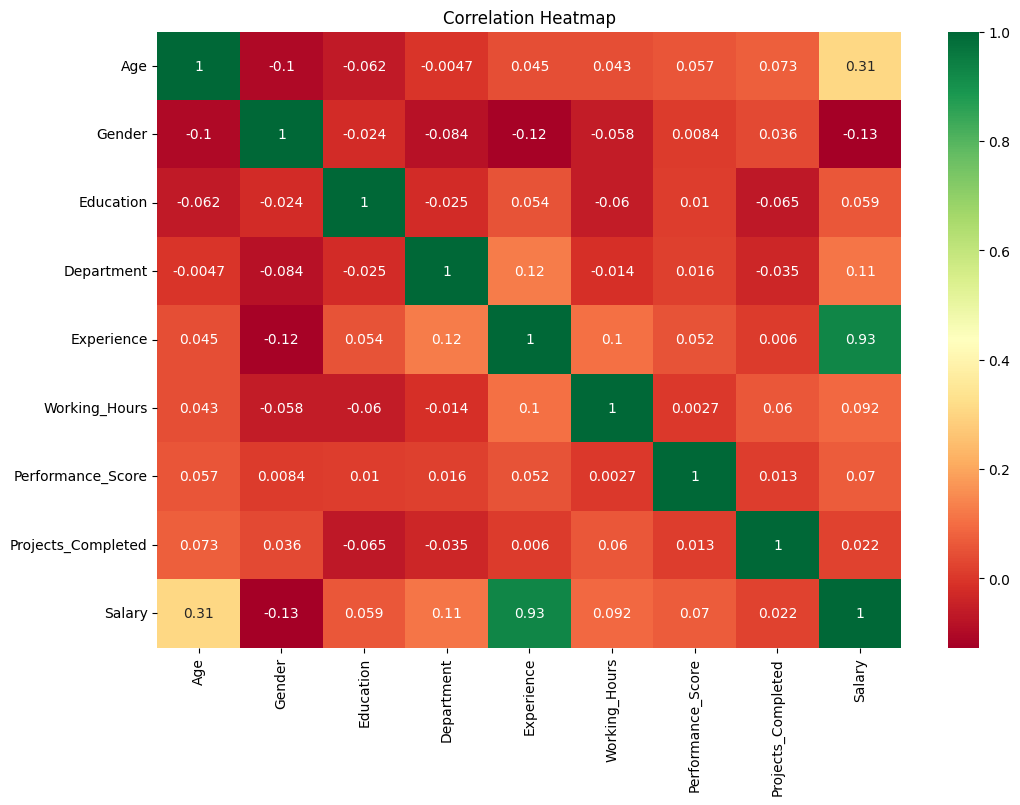

In [ ]:
# 2. Correlation Heatmap
# Encode categorical data to include in heatmap
df_encoded = df.copy()
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.drop(columns=['Employee_ID']).corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')


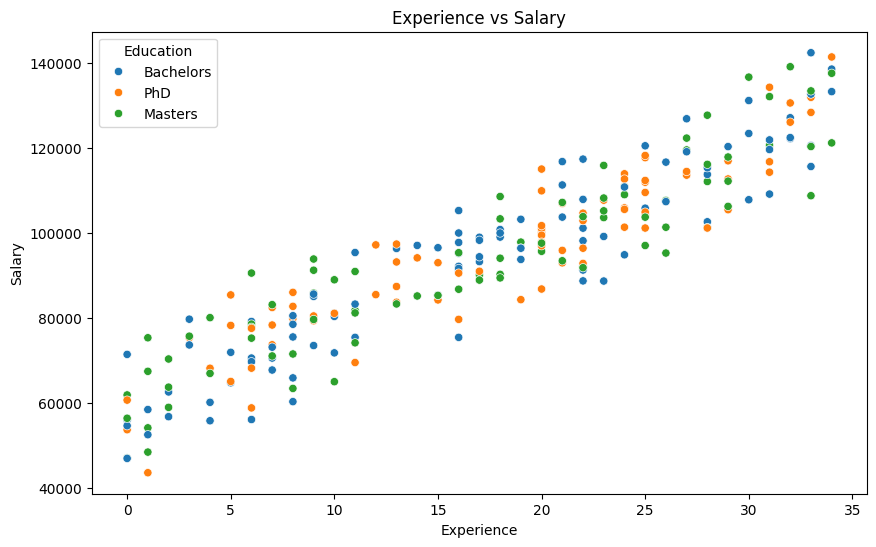

In [ ]:
# 3. Experience vs Salary (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Experience', y='Salary', hue='Education')
plt.title('Experience vs Salary')
plt.savefig('experience_vs_salary.png')


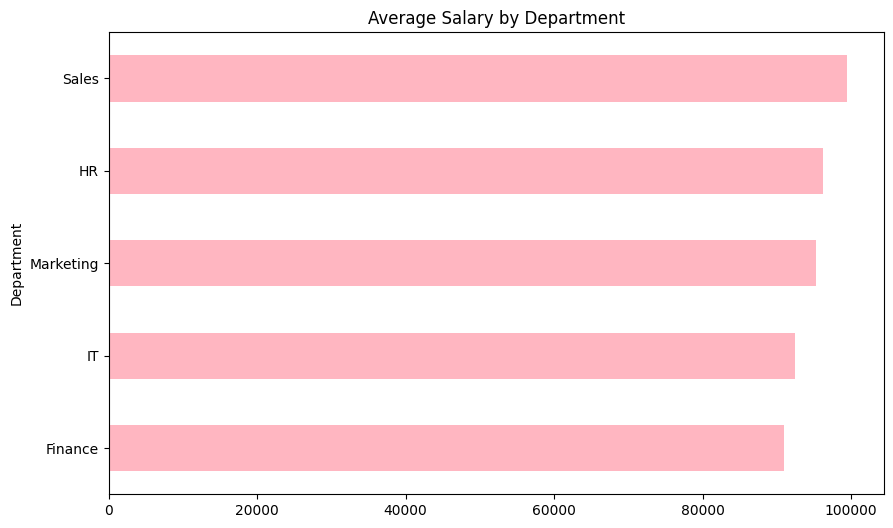

In [ ]:
# 4. Department-wise Comparison (Bar Chart)
plt.figure(figsize=(10, 6))
avg_salary_dept = df.groupby('Department')['Salary'].mean().sort_values()
avg_salary_dept.plot(kind='barh', color='lightpink')
plt.title('Average Salary by Department')
plt.savefig('department_comparison.png')


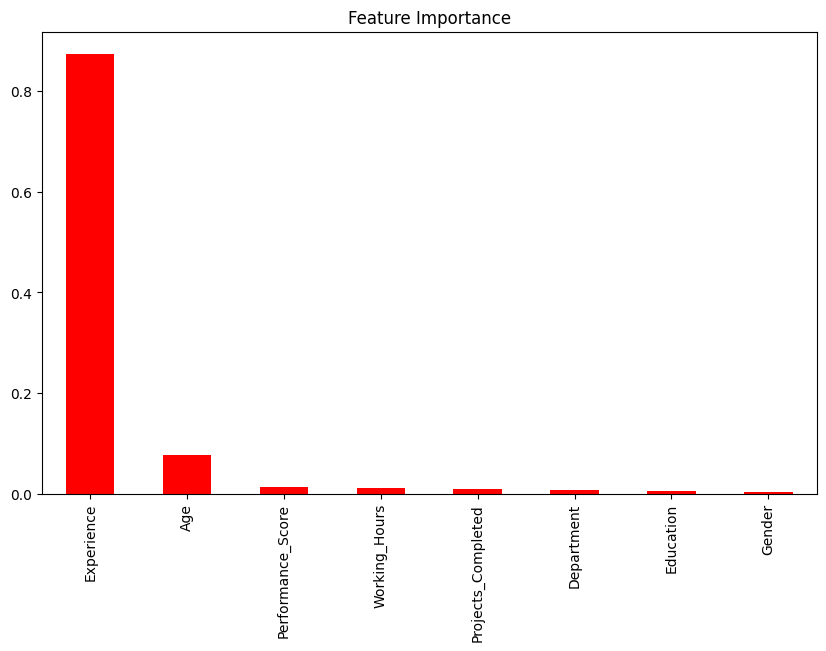

In [ ]:
# 5. Feature Importance Graph
X = df_encoded.drop(columns=['Employee_ID', 'Salary'])
y = df_encoded['Salary']
rf = RandomForestRegressor().fit(X, y)

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='bar', color='red')
plt.title('Feature Importance')
plt.savefig('feature_importance.png')

**Step-5**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

# 1. Load the dataset
df = pd.read_csv('employee_data.csv')

# 2. Preprocessing
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df[col] = le.fit_transform(df[col])

# Create Categories for Classification (Low, Medium, High)
bins = [0, df['Salary'].quantile(0.33), df['Salary'].quantile(0.66), np.inf]
df['Salary_Category'] = pd.cut(df['Salary'], bins=bins, labels=['Low', 'Medium', 'High'])
df['Salary_Cat_Encoded'] = le.fit_transform(df['Salary_Category'])

# Features and Targets
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category', 'Salary_Cat_Encoded'], axis=1)
y_reg = df['Salary']
y_clf = df['Salary_Cat_Encoded']

# Split Data
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- A. Linear Regression (Regression Metrics) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)
y_pred_lr = lr.predict(X_test_scaled)

print("--- Linear Regression Evaluation ---")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred_lr):.2f}")
print(f"MSE:  {mean_squared_error(y_test_reg, y_pred_lr):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_lr):.4f}")

# --- B. Logistic Regression (Classification Metrics) ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_scaled)

print("\n--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_log)*100:.2f}%")
print("Confusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_log))

# --- C. Random Forest (Comparison) ---
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

print("\n--- Random Forest Regressor Evaluation ---")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred_rf_reg):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_rf_reg):.4f}")

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_scaled)

print("\n--- Random Forest Classifier Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rf_clf)*100:.2f}%")
print("Confusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_rf_clf))

--- Linear Regression Evaluation ---
MAE:  4396.17
MSE:  28121118.27
R2 Score: 0.9466

--- Logistic Regression Evaluation ---
Accuracy: 84.62%
Confusion Matrix:
[[18  0  1]
 [ 0 17  2]
 [ 2  3  9]]

--- Random Forest Regressor Evaluation ---
MAE:  4818.32
R2 Score: 0.9280

--- Random Forest Classifier Evaluation ---
Accuracy: 82.69%
Confusion Matrix:
[[17  0  2]
 [ 0 17  2]
 [ 2  3  9]]
